Analysis of the aggregated cell survival data
- With classic LQ fit
- With unweighted Rorvik

In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os
import statsmodels.api as sm
import seaborn
from scipy.optimize import curve_fit

In [ ]:
def write_LET(rad_type):
    if rad_type == 'X':
        return 1
    if rad_type == 'Proton L':
        return 1.26
    if rad_type == 'Proton H':
        return 12.33

In [46]:
def Parse_data(input):
    #Split colony counting data into cell survival for each sample, normalised to control

    #inputs:
    #input = dataframe with the dose, plated cells and count of each triplicatefor each sample

    triplicates = ['Count_1', 'Count_2', 'Count_3']
    #Isolate controls
    control_data = input[input['Dose'] == 0]
    control_survival = control_data[triplicates].mean(axis=1)/control_data['Plated']
    dev = control_data[triplicates].std()/control_data['Plated']

    #Write other data to output with dose and survival
    output = pd.DataFrame(columns=['Dose', 'LET', 'Survival'])

    for row in input.itertuples():
        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_1/row.Plated)/control_survival
        newrow['Survival'] = float(survival.iloc[0])
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_2/row.Plated)/control_survival
        newrow['Survival'] = float(survival.iloc[0])
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

        newrow = {}
        newrow['Dose'] = row.Dose
        survival = (row.Count_3/row.Plated)/control_survival
        newrow['Survival'] = float(survival.iloc[0])
        newrow['LET'] = write_LET(input.tail(1)['Rad'].item())
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

    return output



In [30]:
def Parse_data_triplicates(input):
    #Split colony counting data into cell survival for each sample, normalised to control

    #inputs:
    #input = dataframe with the dose, plated cells and count of each triplicatefor each sample

    triplicates = ['Count_1', 'Count_2', 'Count_3']
    #Isolate controls
    control_data = input[input['Dose'] == 0]
    control_survival = control_data[triplicates].mean(axis=1)/control_data['Plated']
    dev = control_data[triplicates].std()/control_data['Plated']

    #Write other data to output with dose and survival
    output = pd.DataFrame(columns=['Dose', 'Survival', 'Dev'])

    for row in input.itertuples():
        newrow = {}
        newrow['Dose'] = row.Dose
        count = (row.Count_1 + row.Count_2 + row.Count_3)/3
        survival = (count/row.Plated)/control_survival
        newrow['Survival'] = float(survival.iloc[0])
        newrow['Dev'] = float((np.std(np.array([row.Count_1, row.Count_2, row.Count_3]))/row.Plated)/control_survival)
        output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)

    return output


In [48]:
#List all results folders
path = r"C:\Users\bhaan\Documents\#Master Degree\Thesis\Thesis_project\Cell survival results"
results_folders = []
for file in os.listdir(path):
    if os.path.isdir(os.path.join(path, file)) == True:
        results_folders.append(file)

#Loop through folders to extract all excels and write to dataframes: df for aggregating all data for Rorvik fit, survival for mean survival per experiment LQ
X_df = pd.DataFrame(columns=['Dose', 'Plated', 'Count_1', 'Count_2', 'Count_3'])
PL_df = pd.DataFrame(columns=['Dose', 'Plated', 'Count_1', 'Count_2', 'Count_3'])
PH_df = pd.DataFrame(columns=['Dose', 'Plated', 'Count_1', 'Count_2', 'Count_3'])

X_rorvik = pd.DataFrame(columns=['Dose', 'LET', 'Survival'])
PL_rorvik = pd.DataFrame(columns=['Dose', 'LET', 'Survival'])
PH_rorvik = pd.DataFrame(columns=['Dose', 'LET', 'Survival'])

X_survival = pd.DataFrame(columns=['Dose', 'Survival', 'Dev'])
PL_survival = pd.DataFrame(columns=['Dose', 'Survival', 'Dev'])
PH_survival = pd.DataFrame(columns=['Dose', 'Survival', 'Dev'])

for folder in results_folders:
    for file in os.listdir(os.path.join(path, folder)):
        if os.path.splitext(os.path.join(path, folder, file))[-1] == '.xlsx':
            #Read in if it's an excel file
            df = pd.read_excel(os.path.join(path, folder, file), index_col=None)

            #Check the radiation type and write to correct dataframe
            if df.tail(1)['Rad'].item() == 'X':
                survival = Parse_data_triplicates(df)
                X_survival = pd.concat([X_survival, survival])
                X_rorvik = pd.concat([X_rorvik, Parse_data(df)])
                X_df = pd.concat([X_df, df])       
            if df.tail(1)['Rad'].item() == 'Proton L':
                survival = Parse_data_triplicates(df)
                PL_df = pd.concat([PL_df, df])
                PL_survival = pd.concat([PL_survival, survival])
                PL_rorvik = pd.concat([X_rorvik, Parse_data(df)])
            if df.tail(1)['Rad'].item() == 'Proton H':
                survival = Parse_data_triplicates(df)
                PH_df = pd.concat([PH_df, df])
                PH_survival = pd.concat([PH_survival, survival])
                PH_rorvik = pd.concat([X_rorvik, Parse_data(df)])


C:\Users\bhaan\AppData\Local\Temp\ipykernel_15664\873986398.py:22: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  newrow['Dev'] = float((np.std(np.array([row.Count_1, row.Count_2, row.Count_3]))/row.Plated)/control_survival)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_15664\873986398.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat([output, pd.DataFrame([newrow])], ignore_index=True)
C:\Users\bhaan\AppData\Local\Temp\ipykernel_15664\3452458136.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns wh

# Perform LQ fit on data

In [2]:
def Perform_LQ_fit(doses, survival):
    #Generate LQ fit

    #inputs:
    #doses = list of used dose levels
    #survival = dictionary with survival data per dose level

    #returns:
    #params = np array containing the two LQ fit parameters
    #LQ function handle for use in further calculations
    
    def LQ_function(d, a, b):
        return -(a*d + b*(np.square(d)))

    xvals = np.array(doses)
    yvals = np.array(survival['Survival'])
    yvals = np.log(yvals)

    p0 = (0.1, 0.1)

    popt, pcov = curve_fit(LQ_function, xvals, yvals, p0=p0, bounds=(0,1))
    
    return popt, LQ_function

In [6]:
#Remove any zero survivals
X_survival = X_survival[X_survival['Survival'] != 0]
PL_survival = PL_survival[PL_survival['Survival'] != 0]
PH_survival = PH_survival[PH_survival['Survival'] != 0]

Dose_levels = [0, 2, 5, 8]
#Perform LQ fit for all
params_x, LQ_func = Perform_LQ_fit(Dose_levels, X_survival)
params_pl, LQ_func = Perform_LQ_fit(Dose_levels, PL_survival)
params_ph, LQ_func = Perform_LQ_fit(Dose_levels, PH_survival)

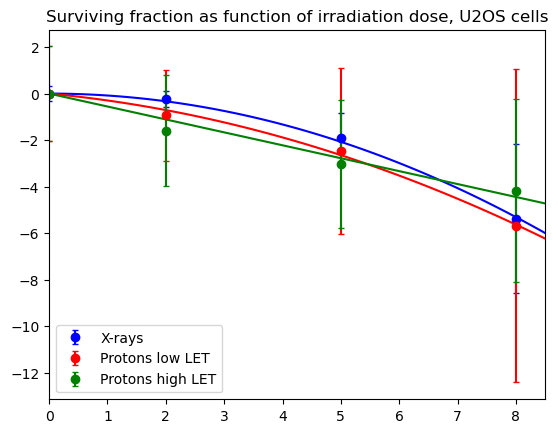

In [7]:
plt.errorbar(Dose_levels, np.log(np.array(X_survival['Survival'])), abs(np.log(X_survival['Dev'])/2), label='X-rays', color='b', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_x[0], params_x[1]), color='b')

plt.errorbar(Dose_levels, np.log(np.array(PL_survival['Survival'])), abs(np.log(np.array(PL_survival['Dev']))), label='Protons low LET', color='r', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_pl[0], params_pl[1]), color='r')

plt.errorbar(Dose_levels, np.log(np.array(PH_survival['Survival'])), abs(np.log(np.array(PH_survival['Dev']))), label='Protons high LET', color='g', fmt='o', capsize=2)
plt.plot(np.linspace(0, 10, 100), LQ_func(np.linspace(0, 10, 100), params_ph[0], params_ph[1]), color='g')

plt.title('Surviving fraction as function of irradiation dose, U2OS cells')
plt.xlim([0, 8.5])
plt.legend()

# Rørvik fit

In [3]:
def Rorvik_fit(sample):
    #input
    #sample = pandas dataframe with dose, let, survival for given radiation type

    #output = fit data

    #Generate a design matrix of the format 'dose, LET*dose, dose^2, log survival
    dose = np.array(sample['Dose'], dtype='float')
    let = np.array(sample['LET'], dtype = 'float')
    X = np.column_stack((dose, dose*let, np.square(dose)))
    y = -(np.log(np.array(sample['Survival'], dtype = 'float')))

    model = sm.OLS(y, X)
    results = model.fit()
    print(results.summary())

    return results.params

In [52]:
#Remove any zero survivals
X_rorvik = X_rorvik[X_rorvik['Survival'] != 0]
PL_rorvik = PL_rorvik[PL_rorvik['Survival'] != 0]
PH_rorvik = PH_rorvik[PH_rorvik['Survival'] != 0]

#Correct X_ray dose
#X_survival['Dose'] = 0.72*X_survival['Dose']

#Aggregate data back into one dataframe
total_data = pd.concat([X_rorvik, PL_rorvik, PH_rorvik])

#Fit curve
params = Rorvik_fit(total_data)

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.928
Model:                            OLS   Adj. R-squared (uncentered):              0.922
Method:                 Least Squares   F-statistic:                              138.4
Date:                Tue, 11 Nov 2025   Prob (F-statistic):                    2.10e-18
Time:                        14:29:32   Log-Likelihood:                         -44.847
No. Observations:                  35   AIC:                                      95.69
Df Residuals:                      32   BIC:                                      100.4
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

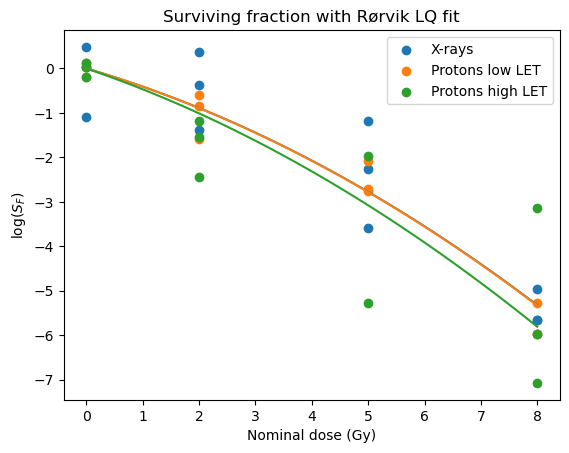

In [54]:
#Plot data
d = np.linspace(0,8,100)
let = X_rorvik['LET'][0]
y = -(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.scatter(X_rorvik['Dose'], np.log(X_rorvik['Survival']), label='X-rays')
plt.plot(d, y)

d = np.linspace(0,8,100)
let = PL_rorvik['LET'][0]
y = -(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.scatter(PL_rorvik['Dose'], np.log(PL_rorvik['Survival']), label='Protons low LET')
plt.plot(d, y)

d = np.linspace(0,8,100)
let = PH_rorvik['LET'][0]
y = -(params[0]*d + params[1]*let*d + params[2]*d*d)
plt.scatter(PH_rorvik['Dose'], np.log(PH_rorvik['Survival']), label='Protons high LET')
plt.plot(d, y)

#Customise
plt.xlabel('Nominal dose (Gy)')
plt.ylabel('log($S_F$)')
plt.title('Surviving fraction with Rørvik LQ fit')
plt.legend()

Attempt to implement RBE model according to Rorvik

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_15664\4238516390.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel('LET (keV/$\mu$m)')


Text(0.5, 0.92, 'RBE as function of dose and LET, Rørvik')

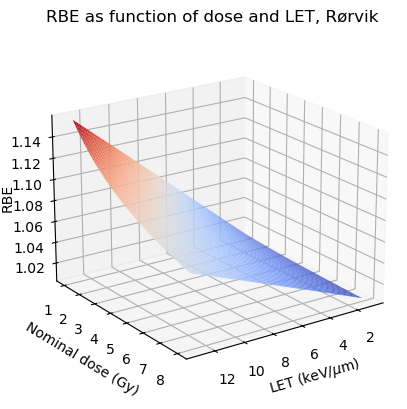

In [55]:
letvals = np.linspace(1, 13, 100)
dosevals = np.linspace(1, 8, 100)
letvals, dosevals = np.meshgrid(letvals, dosevals)

a_x = params[0]
b_x = params[2]
k = params[1]

RBEmin = 1
RBEmax = 1 + (k/a_x)*letvals
A_B = a_x/b_x

squareterm = np.square(A_B) + 4*dosevals*A_B*RBEmax + 4*np.square(dosevals)*np.square(RBEmin)
RBE = (1/(2*dosevals))*(np.sqrt(squareterm) - A_B)

fig = plt.figure()

ax1 = fig.add_subplot(1, 1, 1, projection='3d')
ax1.view_init(elev=20, azim=55, roll=0)
ax1.plot_surface(letvals, dosevals, RBE, cmap = 'coolwarm')
ax1.set_xlabel('LET (keV/$\mu$m)')
ax1.set_ylabel('Nominal dose (Gy)')
ax1.set_zlabel('RBE', rotation=90)
ax1.zaxis.labelpad=-0.8 
ax1.set_title('RBE as function of dose and LET, Rørvik')


<>:2: SyntaxWarning: invalid escape sequence '\m'
<>:2: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_15664\1626334991.py:2: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('LET (keV/$\mu$m)')


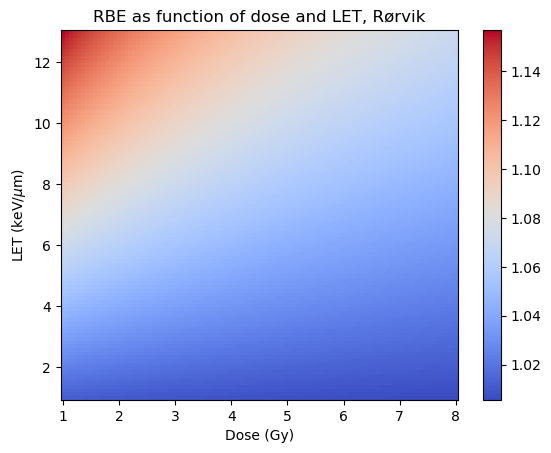

In [56]:
plt.pcolormesh(dosevals, letvals, RBE, cmap='coolwarm')
plt.ylabel('LET (keV/$\mu$m)')
plt.xlabel('Dose (Gy)')
plt.title('RBE as function of dose and LET, Rørvik')
plt.colorbar()